In [1]:
import matplotlib.pyplot as plt
from io import StringIO
import pandas as pd
import numpy as np

In [2]:
colors = ['#00008B', '#FFA500', '#FF0000', '#B22222']  # Define colors for the 4 scenarios


In [3]:
# Raw data as a string
data = """
abbre,ssp126,ssp245,ssp370,ssp585
hsg, 	2020,	2019,	2021,	2021
dsk,	2026,	2027,	2029,	2032
xhl,	2042,	2053,	2055,	2049
slglk,	2042,	2054,	2056,	2058
kq,		2055,	2077,	2074,	2078
wlwt,	2064,	2077,	2093,	2084
tgzlk,	2069,	2080,	2094,	2094
"""

# Use StringIO to simulate a file
data_io = StringIO(data)

# Read the data into a DataFrame
peak_water_df = pd.read_csv(data_io,index_col=0)

peak_water_df

,ssp126,ssp245,ssp370,ssp585
abbre,,,,
hsg,2020,2019,2021,2021
dsk,2026,2027,2029,2032
xhl,2042,2053,2055,2049
slglk,2042,2054,2056,2058
kq,2055,2077,2074,2078
wlwt,2064,2077,2093,2084
tgzlk,2069,2080,2094,2094


In [4]:
# The reservior staorage is half in some basins
# Create the DataFrame
basin_df = pd.DataFrame({
    "Area": {
        "dsk": 18658.8,
        "hsg": 4316.58,
        "kq": 46986.12,
        "slglk": 19275.39,
        "tgzlk": 14811.93,
        "wlwt": 38722.68,
        "xhl": 12948.48
    },
    "Storage": {
        "dsk": 206905000,
        "hsg": 206905000,
        "kq": 4674390000,  # corrected value from your input
        "slglk": 149195000,
        "tgzlk": 320170000,
        "wlwt": 320170000,
        "xhl": 149195000
    }
})

basin_df

           Area     Storage
dsk    18658.80   206905000
hsg     4316.58   206905000
kq     46986.12  4674390000
slglk  19275.39   149195000
tgzlk  14811.93   320170000
wlwt   38722.68   320170000
xhl    12948.48   149195000


In [5]:
# Mapping from region → stations
region_to_stations = {
    "Aksu": ["xhl",'slglk'],
    "Bayingol": ["hsg", "dsk"],
    "Hotan": ["wlwt", "tgzlk"],
    "Kashgar": ["kq"]
}

In [6]:
Eco_series = pd.Series(
    {
        "Bayingol": 1.148,
        "Aksu": 1.499,
        "Kashgar": 1.424,
        "Hotan": 1.195
    },
    name="Eco_value"
)


In [22]:
glacier_df_dict = dict()

In [27]:
for ssp in ['ssp126','ssp245','ssp370','ssp585']:
    glacier_df = pd.read_csv(rf"K:\GlacierData\glacier_mon_pre\R131415_glac_runoff_fixed_monthly_1set_2000_2100-{ssp}-Batch.csv",index_col=0)

    glacier_df.index = pd.to_datetime(glacier_df.index)
    glacier_df.index = glacier_df.index.to_period('M')
    glacier_df_dict[ssp] = glacier_df


In [7]:
station_list = ['hsg', 'dsk', 'xhl', 'slglk', 'kq', 'wlwt', 'tgzlk']

In [8]:
import pandas as pd

# 1. Initialize the Excel writer outside the loop
file_path = r"F:\geodata\river_runoff_obs\output\glacier_fractions.xlsx"
with pd.ExcelWriter(file_path) as writer:

    for i, ssp in enumerate(['ssp126','ssp245','ssp370','ssp585']):
        frss_dict = {}
        glacier_fraction_df = pd.DataFrame()

        for j, station in enumerate(station_list):
            station_df = pd.read_csv(
                rf"F:\geodata\river_runoff_obs\output\{j+1}_{station}_imputMF_mean_{ssp}_r1i1p1f1_daily_fixed.csv",
                index_col=0
            )
            station_df.index = pd.to_datetime(station_df.index)
            station_df.drop(station_df.loc['2060-01-01':'2060-12-31'].index, inplace=True)

            area = basin_df.loc[station, 'Area']
            station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)

            annual_station_df = station_df.resample('YE').mean()
            annual_station_df.index = annual_station_df.index.year
            annual_station_df['gr'] *= (12 / 365 / 24 / 60 / 60)
            glacier_fraction_df[station] = annual_station_df['gr'] / annual_station_df['runoff_fixed']

        # 2. Write the current SSP dataframe to a specific sheet
        glacier_fraction_df.to_excel(writer, sheet_name=ssp)

# The file is automatically saved when exiting the 'with' block


In [9]:
import pandas as pd

# 1. Initialize the Excel writer outside the loop
file_path = r"F:\geodata\river_runoff_obs\output\prcp_fractions.xlsx"
with pd.ExcelWriter(file_path) as writer:

    for i, ssp in enumerate(['ssp126','ssp245','ssp370','ssp585']):
        frss_dict = {}
        glacier_fraction_df = pd.DataFrame()

        for j, station in enumerate(station_list):
            station_df = pd.read_csv(
                rf"F:\geodata\river_runoff_obs\output\{j+1}_{station}_imputMF_mean_{ssp}_r1i1p1f1_daily_fixed.csv",
                index_col=0
            )
            station_df.index = pd.to_datetime(station_df.index)
            station_df.drop(station_df.loc['2060-01-01':'2060-12-31'].index, inplace=True)

            area = basin_df.loc[station, 'Area']
            station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)

            annual_station_df = station_df.resample('YE').mean()
            annual_station_df.index = annual_station_df.index.year
            annual_station_df['gr'] *= (12 / 365 / 24 / 60 / 60)
            glacier_fraction_df[station] = annual_station_df['pre_daily'] / annual_station_df['runoff_fixed']

        # 2. Write the current SSP dataframe to a specific sheet
        glacier_fraction_df.to_excel(writer, sheet_name=ssp)

# The file is automatically saved when exiting the 'with' block


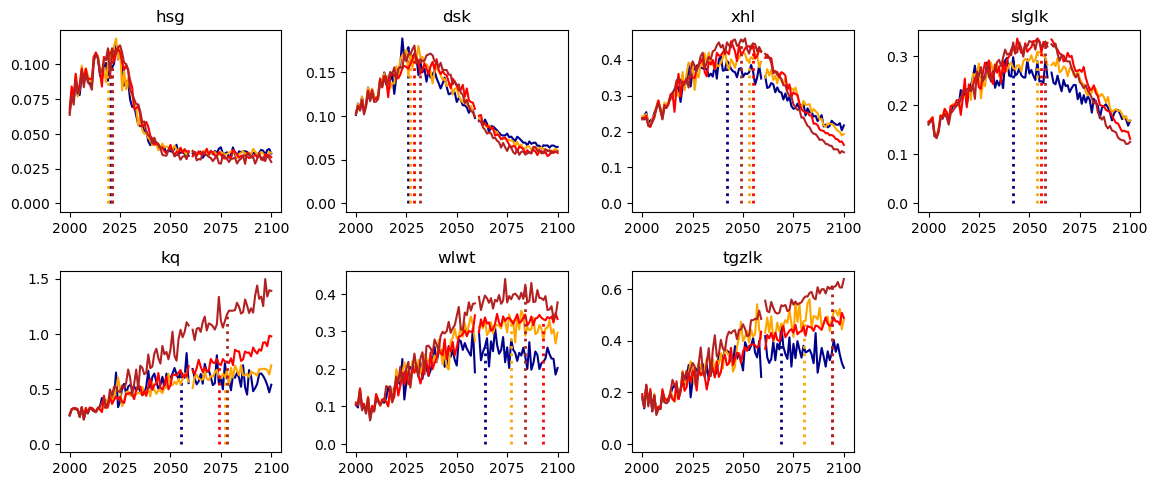

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a figure with 7 subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(11.69, 8.27 * 0.6))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten for easier indexing
# Remove the last unused subplot (if 7 subfigures)
fig.delaxes(axes[-1])

file_path = r"F:\geodata\river_runoff_obs\output\glacier_fractions_station.xlsx"

with pd.ExcelWriter(file_path) as writer:
    for j, station in enumerate(station_list):
        ax = axes[j]  # Select the current subplot
        glacier_fraction_df = pd.DataFrame()

        scenarios = ['ssp126','ssp245','ssp370','ssp585']

        for i, ssp in enumerate(scenarios):
            # 1. Load and process data
            station_df = pd.read_csv(
                rf"F:\geodata\river_runoff_obs\output\{j+1}_imputMF_{ssp}_daily_30_fixed_mean.csv",
                index_col=0
            )
            station_df.index = pd.to_datetime(station_df.index)
            station_df.drop(station_df.loc['2060-01-01':'2060-12-31'].index, inplace=True, errors='ignore')

            area = basin_df.loc[station, 'Area']
            station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)
            if station == 'kq':
                station_df['gr'] = glacier_df_dict[ssp][station]

            annual_station_df = station_df.resample('YE').mean()
            annual_station_df.index = annual_station_df.index.year
            annual_station_df['gr'] *= (12/ 365 / 24 / 60 / 60)

            # 2. Update the DataFrame BEFORE plotting
            glacier_fraction_df[ssp] = annual_station_df['gr'] / annual_station_df['runoff_fixed']

            # 3. Now you can plot safely
            peak_year = float(peak_water_df.loc[station, ssp])

            ax.vlines(
                x=peak_year,
                ymin=0,
                ymax=glacier_fraction_df.loc[peak_year, ssp],
                colors=colors[i],
                linestyles='dotted',
                linewidth=2,
                label='Peak Water' if i == 0 else "" # Avoid duplicate labels in legend
            )

            ax.plot(
                glacier_fraction_df.index,
                glacier_fraction_df[ssp],
                label=ssp,
                color=colors[i]
            )

        ax.set_title(station)
    # 2. Hide the 8th subplot if you only have 7 stations
    if len(station_list) < len(axes):
        axes[-1].axis('off')

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Save the Excel file (already in your logic)
    glacier_fraction_df.to_excel(writer, sheet_name=station)

# Final show after the loop finishes
plt.show()

In [40]:
annual_station_df

,dis_daily,tm_daily,pre_daily,ep_daily,Projected_Runoff_daily,Projected_Evaporation_daily,dis_month,tm_month,pre_month,ep_month,gr,Projected_Runoff_month,Projected_Evaporation_month,min_runoff,min_ep,mean_runoff,mean_ep,runoff_fixed,ep_fixed
time_daily,,,,,,,,,,,,,,,,,,,
2000,69.997760,268.943994,17.843532,90.335137,82.715941,85.377857,75.455391,272.261791,0.000017,97.106687,15.393660,84.178037,94.876797,5.575822,14.485933,82.715941,85.377857,84.178037,3.162560
2001,85.013014,269.230484,24.436046,92.889260,73.905145,85.222219,85.013014,270.981670,0.000017,92.889260,11.452785,79.799895,89.568979,4.821287,20.327806,73.905145,85.222219,79.799895,2.985633
2002,77.429781,270.803428,20.982070,91.981534,83.263195,89.995854,77.429781,271.462890,0.000018,91.981534,19.633664,85.332426,90.594737,3.188788,17.226395,83.263195,89.995854,85.332426,3.019825
2003,75.907479,269.308524,20.966076,95.370575,70.716007,84.832517,75.907479,270.743465,0.000018,95.370575,10.791163,73.914386,88.392000,5.344304,15.149738,70.716007,84.832517,73.914386,2.946400
2004,56.998661,269.562221,15.165038,91.781530,85.622182,86.019873,56.998919,270.939101,0.000018,91.781530,15.920256,78.771890,89.735103,3.764506,16.137563,85.622182,86.019873,78.771890,2.991170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,NaN,274.002874,40.545095,NaN,123.194132,114.572481,NaN,275.871342,0.000024,NaN,196.403395,321.147420,150.296925,4.699249,21.363489,123.196177,114.602823,321.146472,5.027494
2097,NaN,274.146532,42.663443,NaN,123.990111,116.042679,NaN,275.995663,0.000025,NaN,217.546536,346.824178,153.748955,5.712015,22.575773,123.990111,116.042679,346.824178,5.124965
2098,NaN,274.404675,38.374273,NaN,126.758955,116.644525,NaN,276.238183,0.000022,NaN,201.752881,332.824736,151.079559,-0.218994,22.141028,126.758955,116.644525,332.824736,5.035985


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = r"F:\geodata\river_runoff_obs\output\glacier_fractions_station.xlsx"

with pd.ExcelWriter(file_path) as writer:
    for j, station in enumerate(station_list):
        ax = axes[j]  # Select the current subplot
        glacier_fraction_df = pd.DataFrame()

        scenarios = ['ssp126','ssp245','ssp370','ssp585']

        for i, ssp in enumerate(scenarios):
            # 1. Load and process data
            station_df = pd.read_csv(
                rf"F:\geodata\river_runoff_obs\output\{j+1}_imputMF_{ssp}_daily_30_fixed_mean.csv",
                index_col=0
            )
            station_df.index = pd.to_datetime(station_df.index)
            station_df.drop(station_df.loc['2060-01-01':'2060-12-31'].index, inplace=True, errors='ignore')

            area = basin_df.loc[station, 'Area']
            station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)

            annual_station_df = station_df.resample('YE').mean()
            annual_station_df.index = annual_station_df.index.year


            annual_station_df['gr'] *= (12)

            if station == 'kq':
                break

time
2000-01-01    0.000000e+00
2000-02-01    0.000000e+00
2000-03-01    0.000000e+00
2000-04-01    0.000000e+00
2000-05-01    4.171807e+05
                  ...     
2100-08-01    9.544569e+07
2100-09-01    3.548686e+07
2100-10-01    0.000000e+00
2100-11-01    0.000000e+00
2100-12-01    0.000000e+00
Freq: MS, Name: dsk, Length: 1212, dtype: float64

In [12]:
f'{j+1}_{station}_imputMF_INM-CM4-8_{ssp}_r1i1p1f1_daily_256_30_fixed.csv'

'7_tgzlk_imputMF_INM-CM4-8_ssp585_r1i1p1f1_daily_256_30_fixed.csv'

In [13]:
annual_station_df['gr']

time_daily
2000    4.854545e+08
2001    3.611750e+08
2002    6.191672e+08
2003    3.403101e+08
2004    5.020612e+08
            ...     
2096    6.193777e+09
2097    6.860548e+09
2098    6.362479e+09
2099    6.010009e+09
2100    6.810132e+09
Name: gr, Length: 101, dtype: float64

In [20]:
# 1. Initialize the Excel writer outside the loop
file_path = r"F:\geodata\river_runoff_obs\output\glacier_fractions_station.xlsx"
with pd.ExcelWriter(file_path) as writer:

    for j, station in enumerate(station_list):
        frss_dict = {}
        glacier_fraction_df = pd.DataFrame()

        for i, ssp in enumerate(['ssp126','ssp245','ssp370','ssp585']):
            station_df = pd.read_csv(
                rf"F:\geodata\river_runoff_obs\output\5_kq_imputMF_INM-CM4-8_{ssp}_r1i1p1f1_daily_256_30_fixed.csv",
                index_col=0
             )
        #     station_df.index = pd.to_datetime(station_df.index)
        #     station_df.drop(station_df.loc['2060-01-01':'2060-12-31'].index, inplace=True)
        #
        #     area = basin_df.loc[station, 'Area']
        #     station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)
        #
        #     annual_station_df = station_df.resample('YE').mean()
        #     annual_station_df.index = annual_station_df.index.year
        #     # annual_station_df['gr'] *= (12 / 365 / 24 / 60 / 60)
        #     glacier_fraction_df[ssp] = annual_station_df['gr'] / annual_station_df['runoff_fixed']
        #
        #     plt.vlines(x=float(peak_water_df.loc[station,ssp]), ymin = 0, ymax = glacier_fraction_df.loc[peak_water_df.loc[station,ssp],ssp], colors=colors[i], linestyles='dotted', linewidth=2, label='Peak Water')
        #     plt.plot(
        #         glacier_fraction_df.index,
        #         glacier_fraction_df[ssp],
        #         label=scenario,
        #         color=colors[i]  # Set the color based on the scenario index
        #     )
        #
        # # 2. Write the current SSP dataframe to a specific sheet
        # glacier_fraction_df.to_excel(writer, sheet_name=station)
        # plt.show()

# The file is automatically saved when exiting the 'with' block


In [15]:
glacier_df = pd.read_csv(r"K:\GlacierData\glacier_mon_pre\R131415_glac_runoff_fixed_monthly_1set_2000_2100-ssp245-Batch.csv",index_col=0)

In [16]:
glacier_df.index = pd.to_datetime(glacier_df.index)

In [18]:
glacier_df.resample('YE').sum()

,dsk,hsg,kq,slglk,tgzlk,wlwt,xhl
time,,,,,,,
2000-12-31,8.719923e+08,5.535779e+07,1.989210e+09,9.965756e+08,9.129261e+08,5.809414e+08,3.599863e+09
2001-12-31,9.223019e+08,6.031039e+07,2.131920e+09,1.031136e+09,7.126988e+08,5.729124e+08,3.791107e+09
2002-12-31,9.472278e+08,6.197665e+07,2.324742e+09,1.066462e+09,1.267448e+09,8.451717e+08,3.887461e+09
2003-12-31,9.607960e+08,6.404986e+07,2.119185e+09,9.168489e+08,7.704393e+08,5.179331e+08,3.524482e+09
2004-12-31,8.343102e+08,5.444342e+07,2.063879e+09,8.764214e+08,1.043523e+09,5.493592e+08,3.272474e+09
...,...,...,...,...,...,...,...
2096-12-31,5.903177e+08,3.393453e+07,8.223864e+09,1.308548e+09,5.160784e+09,3.047213e+09,5.551509e+09
2097-12-31,5.818531e+08,3.329202e+07,7.695216e+09,1.245321e+09,5.098505e+09,2.615220e+09,5.566153e+09
2098-12-31,5.911241e+08,3.394802e+07,7.728794e+09,1.232056e+09,4.989206e+09,2.835721e+09,5.360297e+09
